In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2, pretrained on ImageNet, without its original classification head
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers — don't retrain what it already learned
base_model.trainable = False

# Add our own classification head for 5 skin condition classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = r"data\resized\train"
val_dir = r"data\resized\val"
test_dir = r"data\resized\test"

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

Found 5791 images belonging to 5 classes.
Found 722 images belonging to 5 classes.
Found 728 images belonging to 5 classes.


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.7536 - loss: 0.6630 - val_accuracy: 0.8587 - val_loss: 0.3973
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 139s 768ms/step - accuracy: 0.8548 - loss: 0.4069 - val_accuracy: 0.8726 - val_loss: 0.3711
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 144s 796ms/step - accuracy: 0.8805 - loss: 0.3422 - val_accuracy: 0.8989 - val_loss: 0.2938
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 159s 880ms/step - accuracy: 0.8895 - loss: 0.3067 - val_accuracy: 0.9114 - val_loss: 0.2990
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 167s 921ms/step - accuracy: 0.8993 - loss: 0.2775 - val_accuracy: 0.9155 - val_loss: 0.2572
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 154s 852ms/step - accuracy: 0.9097 - loss: 0.2456 - val_accuracy: 0.9003 - val_loss: 0.2958
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 155s 857ms/step - accuracy: 0.9223 - loss: 0.2255 - val_accuracy: 0.9127 - val_loss: 0.2726
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 156s 859ms/step - accuracy: 0.9251 - lo

In [11]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 650ms/step - accuracy: 0.9190 - loss: 0.2568
Test Accuracy: 0.9190
Test Loss: 0.2568


Found 728 images belonging to 5 classes.


23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 470ms/step
              precision    recall  f1-score   support

        acne       0.91      0.89      0.90       203
 blackheades       0.88      0.89      0.89       133
  dark spots       0.86      0.88      0.87       121
       pores       0.96      0.96      0.96       109
    wrinkles       0.98      0.98      0.98       162

    accuracy                           0.92       728
   macro avg       0.92      0.92      0.92       728
weighted avg       0.92      0.92      0.92       728



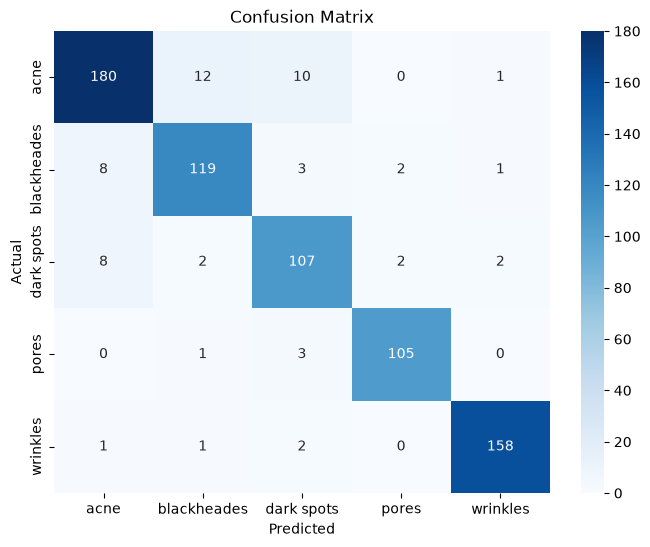

In [14]:
test_generator_eval = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False  # critical: keeps prediction order aligned with true labels
)

y_true = test_generator_eval.classes
class_labels = list(test_generator_eval.class_indices.keys())

y_pred_probs = model.predict(test_generator_eval)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()